In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
df_old = pd.read_csv('PreProcessed_IBM_Telco_Customer_Churn_Cleaned.csv')
df_new = pd.read_csv('IBM_Telco_Churn_Complex_200K.csv')
df = pd.concat([df_old, df_new], ignore_index=True)

print("Combined shape:", df.shape)
print("Duplicate customerIDs:", df['customerID'].duplicated().sum())
print(df['Churn'].value_counts())

Combined shape: (207043, 23)
Duplicate customerIDs: 0
Churn
Yes    110901
No      96142
Name: count, dtype: int64


In [ ]:

df = df.drop_duplicates()
df = df.drop_duplicates(subset='customerID', keep='last')

print("After dedup:", df.shape)
df = df.drop(columns=['customerID', 'TenureGroup'])

After dedup: (207043, 23)


In [ ]:

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df = pd.get_dummies(df, columns=['gender'], drop_first=False)
df['gender_Female'] = df['gender_Female'].astype(int)
df['gender_Male'] = df['gender_Male'].astype(int)
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
              'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print(df.shape)
print(df.select_dtypes(include='object').columns.tolist())  # must be []

(207043, 33)
[]


In [5]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train_scaled.shape, "Test:", X_test_scaled.shape)
print("Train churn rate:", y_train.mean())

Train: (165634, 32) Test: (41409, 32)
Train churn rate: 0.5356448555248319


In [6]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(1.0767620558293136), 1: np.float64(0.9334543118314717)}


In [7]:
def build_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

model = build_model(X_train_scaled.shape[1])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,105 (59.00 KB)

 Trainable params: 15,105 (59.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,          
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8354 - auc: 0.8963 - loss: 0.4057 - val_accuracy: 0.8415 - val_auc: 0.9064 - val_loss: 0.3858
Epoch 2/100
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8422 - auc: 0.9033 - loss: 0.3913 - val_accuracy: 0.8406 - val_auc: 0.9062 - val_loss: 0.3895
Epoch 3/100
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8428 - auc: 0.9046 - loss: 0.3889 - val_accuracy: 0.8417 - val_auc: 0.9068 - val_loss: 0.3862
Epoch 4/100
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8431 - auc: 0.9053 - loss: 0.3876 - val_accuracy: 0.8408 - val_auc: 0.9065 - val_loss: 0.3927
Epoch 5/100
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8435 - auc: 0.9055 - loss: 0.3870 - val_accuracy: 0.8413 - val_auc: 0.9072 - val_loss: 0.3892
Epoch 6/100
2071/2071 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8433 - auc: 0.9059 - loss: 0.3863 - val_accuracy: 0.8416 - val_auc: 0.9064 - val_loss: 0.3890
Epoch 7/100
2071/2071 

In [9]:
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

test_loss, test_acc, test_auc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test AUC: {test_auc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

1295/1295 ━━━━━━━━━━━━━━━━━━━━ 1s 580us/step
Test Accuracy: 0.8409
Test AUC: 0.9055
Test Loss: 0.3878

Classification Report:

              precision    recall  f1-score   support

    No Churn       0.83      0.82      0.83     19229
       Churn       0.85      0.86      0.85     22180

    accuracy                           0.84     41409
   macro avg       0.84      0.84      0.84     41409
weighted avg       0.84      0.84      0.84     41409



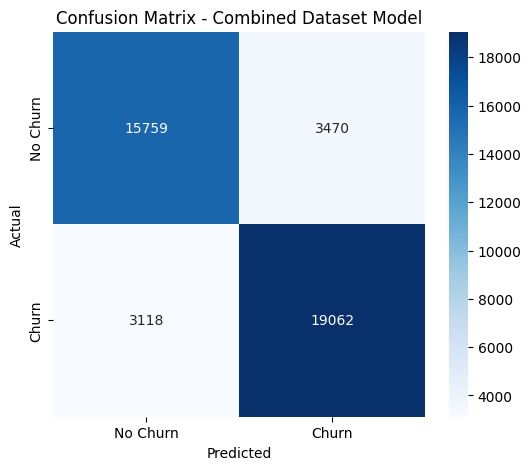

In [10]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Combined Dataset Model')
plt.show()

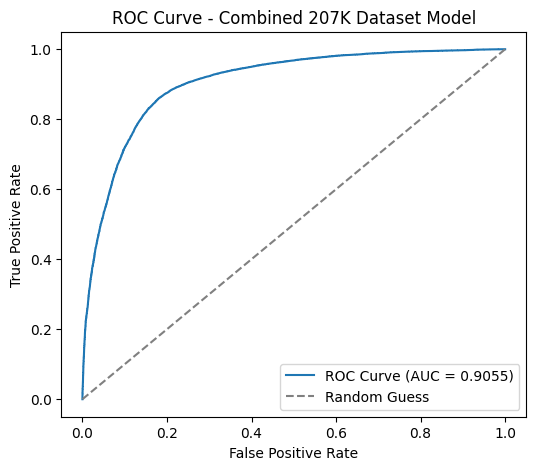

In [11]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {test_auc:.4f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Combined 207K Dataset Model')
plt.legend()
plt.show()

In [ ]:
def predict_churn_batch(new_data, scaler, model, reference_columns, threshold=0.5):
    customer_ids = new_data['customerID'].copy()
    
    df_new = new_data.drop(columns=['customerID'])
    if 'TenureGroup' in df_new.columns:
        df_new = df_new.drop(columns=['TenureGroup'])
    if 'Churn' in df_new.columns:
        df_new = df_new.drop(columns=['Churn'])
    
    df_new['TotalCharges'] = pd.to_numeric(df_new['TotalCharges'], errors='coerce').fillna(0)
    df_new = pd.get_dummies(df_new, columns=['gender'], drop_first=False)
    
    binary_map = {'Yes': 1, 'No': 0}
    for col in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']:
        df_new[col] = df_new[col].map(binary_map)
    
    multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                  'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                  'Contract', 'PaymentMethod']
    df_new = pd.get_dummies(df_new, columns=multi_cols, drop_first=True)
    
    bool_cols = df_new.select_dtypes(include='bool').columns
    df_new[bool_cols] = df_new[bool_cols].astype(int)
    
    df_new = df_new.reindex(columns=reference_columns, fill_value=0)
    df_new_scaled = scaler.transform(df_new)
    
    probs = model.predict(df_new_scaled, verbose=0).flatten()
    preds = (probs > threshold).astype(int)
    
    result = pd.DataFrame({
        'customerID': customer_ids,
        'Churn_Probability': probs.round(4),
        'Predicted_Churn': ['Yes' if p == 1 else 'No' for p in preds]
    })
    
    return result

new_data = pd.read_csv('new_and_updated_customers.csv')
results = predict_churn_batch(new_data, scaler, model, X.columns, threshold=0.5)
print(results)

   customerID  Churn_Probability Predicted_Churn
0  7590-VHVEG             0.3313              No
1  5575-GNVDE             0.0584              No
2  3668-QPYBK             0.8770             Yes
3   CUST-2001             0.9742             Yes
4   CUST-2002             0.9698             Yes
5   CUST-2003             0.0541              No
6   CUST-2004             0.7527             Yes
